# Detection Rate Calculator

In [1]:
# --- Installation & Setup (Colab only) ---

import sys

# Check if the env run under Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess

    # Remove old clone if exists
    subprocess.run(["rm", "-rf", "cbc-population-distributions"])

    # Clone our GitHub repository into the Colab environment
    !git clone https://github.com/weizmannk/cbc-population-distributions.git
    %cd cbc-population-distributions

    # Install uv (fast dependency manager) and sync dependencies from uv.lock
    !pip install -q uv
    !uv sync

    # (Optional) Add the repo to PYTHONPATH if it's not an installable package

    import glob
    import os

    pyver = f"{sys.version_info.major}.{sys.version_info.minor}"
    venv_site = glob.glob(f".venv/lib/python{pyver}/site-packages")[0]
    sys.path.insert(0, os.path.abspath(venv_site))
    sys.path.insert(0, os.path.abspath("."))

    print("Environment ready. You can now run the rest of the notebook.")

## Imports and Setup

In [2]:
import logging

import numpy as np
import seaborn as sns
from astropy import units as u
from astropy.cosmology import Planck15 as cosmo
from astropy.cosmology import z_at_value
from astropy.table import Table, join
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from scipy import stats

# Import Poisson utility functions
if IN_COLAB:
    from scripts.poisson_rate_utils import (
        format_with_errorbars,
        poisson_lognormal_rate_quantiles,
    )
else:
    # This notebook lives at scripts/notebooks/, poisson_rate_utils.py is a
    # sibling of notebooks/, so scripts/ needs to be on sys.path.
    sys.path.insert(0, "..")
    from poisson_rate_utils import (
        format_with_errorbars,
        poisson_lognormal_rate_quantiles,
    )

In [3]:
# ============================================================================
# logging / warning configuration
# ============================================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

---

## 1. Function Definitions

In [4]:
def build_rates_table(fiducial_rates, mass_fractions, combined_rate=False):
    """
    Build a table with fiducial rates, attaching mass fractions and the
    log-normal (mu, sigma) parameters used by calculate_detection_rates.

    Parameters
    ----------
    fiducial_rates : dict
        Dictionary with population names as keys and rate dicts as values
    mass_fractions : dict
        Dictionary with population names as keys and fractions as values
    combined_rate : bool
        True if fiducial_rates gives a single combined rate for the whole
        population (the same lower/mid/upper repeated for every class),
        which needs multiplying by mass_fractions to become class-specific.
        This is the case for every model here: the whole simulated
        population is drawn together from one normalised model at one
        combined rate, so splitting by each model's own mass fraction is
        what keeps the normalisation self-consistent with what was
        actually simulated.

    Returns
    -------
    rates_table : astropy.table.Table
        Table with adjusted rates
    """
    rows = []
    for pop in ["BNS", "NSBH", "BBH"]:
        row = {"population": pop}
        row.update(fiducial_rates[pop])
        rows.append(row)

    rates_table = Table(rows)

    # Add mass fractions
    rates_table["mass_fraction"] = [
        mass_fractions["BNS"],
        mass_fractions["NSBH"],
        mass_fractions["BBH"],
    ]

    if combined_rate:
        for key in ["lower", "mid", "upper"]:
            rates_table[key] *= rates_table["mass_fraction"]

    # Calculate log-normal parameters (mu and sigma)
    # Assuming log-normal distribution where lower=5% and upper=95%
    rates_table["fiducial_log_rate"] = np.log(rates_table["mid"])

    # For log-normal: 90% interval
    standard_90pct_interval = np.diff(stats.norm.interval(0.9))[0]

    rates_table["fiducial_log_rate_err"] = (
        np.log(rates_table["upper"]) - np.log(rates_table["lower"])
    ) / standard_90pct_interval

    return rates_table


def calculate_detection_rates(
    run_name, run_config, rates_table, prob_quantiles=[0.05, 0.5, 0.95]
):
    """
    Calculate detection rates for a specific observing run.

    Parameters
    ----------
    run_name : str
        Name of the observing run
    run_config : dict
        Dictionary with 'duration', 'sim_rate', and 'detections'
    rates_table : astropy.table.Table
        Table with fiducial rates and parameters
    prob_quantiles : list
        Probability quantiles [lower, median, upper]

    Returns
    -------
    results : dict
        Dictionary with 'low', 'mid', 'high' estimates for each population
    """
    # Convert simulation rate to Gpc^-3 yr^-1
    sim_rate_gpc = (run_config["sim_rate"] / (u.Mpc**3 * u.yr)).to(u.Gpc**-3 * u.yr**-1)

    results = {"low": {}, "mid": {}, "high": {}}

    for pop in ["BNS", "NSBH", "BBH"]:
        # Get rate info for this population
        rates_row = rates_table[rates_table["population"] == pop]

        # Effective rate for this population
        rate = sim_rate_gpc * rates_row["mass_fraction"][0]

        # Calculate mu for this run
        detection_count = run_config["detections"][pop]
        mu = (
            rates_row["fiducial_log_rate"][0]
            + np.log(run_config["duration"])
            + np.log(detection_count / rate.value)
        )
        sigma = rates_row["fiducial_log_rate_err"][0]

        # Calculate quantiles using Poisson-lognormal distribution
        lo, mid, hi = poisson_lognormal_rate_quantiles(
            np.asarray(prob_quantiles), mu, sigma
        )

        # Round
        lo = int(np.floor(lo))
        mid = int(np.round(mid))
        hi = int(np.ceil(hi))

        # Format with error bars
        mid_str, lo_str, hi_str = format_with_errorbars(mid, lo, hi)

        results["low"][pop] = lo_str
        results["mid"][pop] = mid_str
        results["high"][pop] = hi_str

    return results


def format_results_table(all_results, observing_runs):
    """
    Format all results into a display table.

    Parameters
    ----------
    all_results : dict
        Dictionary of results for each run
    observing_runs : dict
        Dictionary of observing run configurations

    Returns
    -------
    results_table : astropy.table.Table
        Formatted table for display
    """
    rows = []
    for run_name, run_stats in all_results.items():
        for pop in ["BNS", "NSBH", "BBH"]:
            rows.append(
                {
                    "run": run_name,
                    "population": pop,
                    "detections": observing_runs[run_name]["detections"][pop],
                    "rate_low": f"-{run_stats['low'][pop]}",
                    "rate_mid": run_stats["mid"][pop],
                    "rate_high": f"+{run_stats['high'][pop]}",
                }
            )

    return Table(
        rows=rows,
        names=("run", "population", "detections", "rate_low", "rate_mid", "rate_high"),
    )


def display_results(results_table, observing_runs):
    """
    Display results in a formatted way.

    Parameters
    ----------
    results_table : astropy.table.Table
        Table with all results
    observing_runs : dict
        Dictionary of observing run configurations
    """
    print("\n" + "=" * 80)
    print("DETECTION RATE RESULTS")
    print("=" * 80)

    for run_name in sorted(set(results_table["run"])):
        run_config = observing_runs[run_name]
        run_data = results_table[results_table["run"] == run_name]

        print(f"\n{'─' * 80}")
        print(f" Run: {run_name}")
        print(f" Duration: {run_config['duration']} years")
        print(f" Sim Rate: {run_config['sim_rate']:.2e} Mpc⁻³ yr⁻¹")
        print(f"{'─' * 80}")
        print(f"{'Population':<12} {'Detected':<12} {'Rate (90% CI)':<30}")
        print(f"{'─' * 80}")

        for row in run_data:
            rate_str = f"{row['rate_mid']} ({row['rate_low']}, {row['rate_high']})"
            print(f"{row['population']:<12} {row['detections']:<12} {rate_str:<30}")

        print(f"{'─' * 80}")

    print("\n" + "=" * 80)
    print("Calculation complete!")
    print("=" * 80 + "\n")


print("Functions defined successfully")

Functions defined successfully


---

## 2. Configuration

### 2.0 Observing Run Durations (from GPS times)

Computed from each run's actual GPS start/end times (GWOSC detector-status
pages), not from calendar-month counting, which is what previously produced
an incorrect "8.23 months" for O4a. A Gregorian month is defined as
365.25/12 = 30.4375 days on average.

O4a/O4b GPS boundaries are the exact ones GWOSC publishes for each run;
O4c's are derived from its GWOSC calendar dates (2025-01-28 to 2025-11-18,
picking up exactly where O4b ends, no gap) since no exact GPS boundary was
published for it here.

In [5]:
# GPS start/end times (seconds), from GWOSC detector-status pages:
# https://gwosc.org/detector_status/O4a/  https://gwosc.org/detector_status/O4b/  https://gwosc.org/detector_status/O4c/
DAYS_PER_MONTH = 365.25 / 12  # average Gregorian month length

runs_gps = {
    "O4a": (1368975618, 1389456018),
    "O4b": (1396796418, 1422118818),
    "O4c": (1422057618, 1447459218),  # 2025-01-28 to 2025-11-18 (calendar-date derived)
}

run_durations = {}
for run_name, (t0, t1) in runs_gps.items():
    duration_days = (t1 - t0) / 86400
    duration_months = duration_days / DAYS_PER_MONTH
    duration_years = duration_days / 365.25
    run_durations[run_name] = {
        "days": duration_days,
        "months": duration_months,
        "years": duration_years,
    }
    print(
        f"{run_name}: {duration_days:.1f} days = {duration_months:.2f} months = {duration_years:.4f} years"
    )

O4a: 237.0 days = 7.79 months = 0.6490 years
O4b: 293.1 days = 9.63 months = 0.8024 years
O4c: 294.0 days = 9.66 months = 0.8049 years


### 2.1 Mass Classification Parameters

In [6]:
# Mass threshold for neutron star classification (Solar masses)

ns_max_mass = 2.5

display(Markdown(rf"Mass threshold: {ns_max_mass} $M_\odot$"))
display(Markdown(rf"- **BNS**: both masses < {ns_max_mass} $M_\odot$"))
display(
    Markdown(
        rf"- **NSBH**: one mass $\geq$ {ns_max_mass} $M_\odot$, one < {ns_max_mass} $M_\odot$"
    )
)
display(Markdown(rf"- **BBH**: both masses $\geq$ {ns_max_mass} $M_\odot$"))

Mass threshold: 2.5 $M_\odot$

- **BNS**: both masses < 2.5 $M_\odot$

- **NSBH**: one mass $\geq$ 2.5 $M_\odot$, one < 2.5 $M_\odot$

- **BBH**: both masses $\geq$ 2.5 $M_\odot$

## See how we split BNS, NSBH and BBH aftere the simulation

In [7]:
# ============================================================================
# Load and process data
# ============================================================================

if IN_COLAB:
    table = Table.read(
        "../../data/injections/injections_IR1_HL.dat", format="ascii.fast_tab"
    )
else:
    table = Table.read(
        "../../data/injections/injections_IR1_HL.dat", format="ascii.fast_tab"
    )


print(len(table))
# Split by source frame mass
z = z_at_value(cosmo.luminosity_distance, table["distance"] * u.Mpc).to_value(
    u.dimensionless_unscaled
)
zp1 = z + 1
source_mass1 = table["mass1"] / zp1
source_mass2 = table["mass2"] / zp1
# ============================================================================
# Print population statistics
# ============================================================================

print(
    f"Number of BNS: {np.sum((source_mass1 < ns_max_mass) & (source_mass2 < ns_max_mass))}, "
    f"Number of NSBH: {np.sum((source_mass1 >= ns_max_mass) & (source_mass2 < ns_max_mass))}, "
    f"Number of BBH: {np.sum((source_mass1 >= ns_max_mass) & (source_mass2 >= ns_max_mass))}"
)

3722


Number of BNS: 226, Number of NSBH: 268, Number of BBH: 3228


### 2.2 Fiducial rate parameters (90% credible intervals in Gpc^-3 yr^-1)

 Table 2. Merger rates from GWTC-4 catalog in units Gpc−3, https://arxiv.org/pdf/2508.18083

In [8]:
# Fiducial rates: 90% credible intervals (Gpc^-3 yr^-1).
#
# The whole simulated population (BNS+NSBH+BBH together) is drawn from a
# single normalised model at a single combined rate, not from three
# independently-normalised populations. So every model here gives one
# combined (lower, mid, upper), the same number repeated for BNS/NSBH/BBH,
# which build_rates_table(combined_rate=True) then splits by each model's
# own mass fraction below. Using the published per-class rates directly
# would mix in a separate, independently-derived selection-effect
# correction per class that has no reason to match this simulation's own
# normalisation.
#
# FullPop and PixelPop combined rates come from data/derived/rate_summary.csv
# (built by scripts/hyperparams/get_hyperparams.py), giving the median and
# 5%/95% interval of each model's total `rate` posterior (GWTC-5.0's own
# median convention). GWTC-3 only ever published one combined R_CBC to
# begin with.
_rate_summary = Table.read("../../data/derived/rate_summary.csv", format="ascii.csv")


def _combined_rate_dict(label):
    (row,) = _rate_summary[_rate_summary["label"] == label]
    rate = {"lower": row["lower_5"], "mid": row["median"], "upper": row["upper_95"]}
    return {"BNS": dict(rate), "NSBH": dict(rate), "BBH": dict(rate)}


fiducial_rates = {
    "fullpop": _combined_rate_dict("GWTC-5.0 FullPop"),
    "pixelpop": _combined_rate_dict("GWTC-5.0 PixelPop"),
    "gwtc3": {
        "BNS": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
        "NSBH": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
        "BBH": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
    },
}

for model, rates in fiducial_rates.items():
    display(Markdown(f"Fiducial merger rates, {model} $(Gpc^{{-3}} yr^{{-1}}$)"))
    for pop, r in rates.items():
        logger.info(f"  {pop:4s}: {r['mid']:.1f} ({r['lower']:.1f} - {r['upper']:.1f})")

Fiducial merger rates, fullpop $(Gpc^{-3} yr^{-1}$)

2026-08-14 04:16:09  INFO        BNS : 100.1 (49.9 - 202.8)


2026-08-14 04:16:09  INFO        NSBH: 100.1 (49.9 - 202.8)


2026-08-14 04:16:09  INFO        BBH : 100.1 (49.9 - 202.8)


Fiducial merger rates, pixelpop $(Gpc^{-3} yr^{-1}$)

...

2026-08-14 04:16:09  INFO        BBH : 68.3 (39.2 - 139.0)


Fiducial merger rates, gwtc3 $(Gpc^{-3} yr^{-1}$)

2026-08-14 04:16:09  INFO        BNS : 240.0 (100.0 - 510.0)


2026-08-14 04:16:09  INFO        NSBH: 240.0 (100.0 - 510.0)


2026-08-14 04:16:09  INFO        BBH : 240.0 (100.0 - 510.0)


### 2.3 Mass Fractions (from CBC population model)

In [9]:
# Mass fractions from CBC population-model samples (not hard-coded): read the
# same mass1/mass2 samples used to generate the injection sets, apply the
# ns_max_mass threshold, and take the fraction in each class.
CBC_SAMPLE_FILES = {
    "fullpop": "../../data/raw/fullpop_gwtc5.h5",
    "pixelpop": "../../data/raw/pixelpop.h5",
}


def compute_mass_fractions(h5_path, ns_max_mass):
    """BNS/NSBH/BBH fractions from a CBC sample table's mass1/mass2 columns."""
    t = Table.read(h5_path)
    m1, m2 = np.asarray(t["mass1"]), np.asarray(t["mass2"])
    n = len(t)
    bns = np.sum((m1 < ns_max_mass) & (m2 < ns_max_mass))
    nsbh = np.sum((m1 >= ns_max_mass) & (m2 < ns_max_mass))
    bbh = n - bns - nsbh
    return {"BNS": bns / n, "NSBH": nsbh / n, "BBH": bbh / n}


mass_fractions = {
    model: compute_mass_fractions(path, ns_max_mass)
    for model, path in CBC_SAMPLE_FILES.items()
}

# GWTC-3 has no CBC sample file in this repo, so its mass fraction is kept
# as previously derived (BNS/NSBH/BBH counts out of 1e6 draws) rather than
# recomputed here.
mass_fractions["gwtc3"] = {
    "BNS": 892762 / 1e6,
    "NSBH": 35962 / 1e6,
    "BBH": 71276 / 1e6,
}

for model, fracs in mass_fractions.items():
    total_fraction = sum(fracs.values())
    logger.info(f"Mass fractions from CBC {model} model:")
    for pop, frac in fracs.items():
        logger.info(f"  {pop:4s}: {frac:.4f} ({frac * 100:.2f}%)")
    logger.info(f"  Total: {total_fraction:.4f}")
    if abs(total_fraction - 1.0) > 0.01:
        logger.info(f"\n Warning: {model} mass fractions don't sum to 1.0")

2026-08-14 04:16:09  INFO      Mass fractions from CBC fullpop model:


2026-08-14 04:16:09  INFO        BNS : 0.5826 (58.26%)


2026-08-14 04:16:09  INFO        NSBH: 0.1823 (18.23%)


2026-08-14 04:16:09  INFO        BBH : 0.2351 (23.51%)


2026-08-14 04:16:09  INFO        Total: 1.0000


...

2026-08-14 04:16:09  INFO      Mass fractions from CBC gwtc3 model:


2026-08-14 04:16:09  INFO        BNS : 0.8928 (89.28%)


2026-08-14 04:16:09  INFO        NSBH: 0.0360 (3.60%)


2026-08-14 04:16:09  INFO        BBH : 0.0713 (7.13%)


2026-08-14 04:16:09  INFO        Total: 1.0000


### 2.4 Observing Runs Configuration

In observing scenarios data there is a file sqlite  file "sqlite3 events.sqlite" where we can read the

the simulation Merger rate, for that use this command line in terminal or import sqlite with python

 Use this command to retrieve comments:

 1- $ sqlite3 events.sqlite

 2- $ select comment from process;


In [10]:
# sim_rate [Mpc^-3 yr^-1] extracted from each run's events.sqlite:
#   sqlite3 events.sqlite "SELECT comment FROM process WHERE program = \'bayestar-inject\';"
# This is the CBC merger rate density used to generate that population
# model's injection set. It depends on the model (fullpop vs pixelpop),
# not on the observing run, so O4a and O4b share the same two values.
SIM_RATES = {
    "fullpop": 4.664849044619958e-06,
    "pixelpop": 2.9357304257800837e-06,
}

RUNS_DIR = "../../runs"


def load_injection_detections(run_dir, ns_max_mass, snr_threshold=8):
    """Classify a run's detected injections into BNS/NSBH/BBH by source-frame
    mass, keeping only events at or above snr_threshold.

    injections.dat stores detector-frame masses (undone here via the (1+z)
    redshift stretch from the luminosity distance column) and is already
    limited to events recovered above the generation threshold (network
    SNR >= 8, see events.sqlite's bayestar-realize-coincs process_params).
    Reading the per-event network SNR from allsky.dat, joined on event ID,
    lets a stricter threshold (e.g. 10) be applied on top of that.
    """
    allsky = Table.read(f"{run_dir}/allsky.dat", format="ascii.fast_tab")
    injections = Table.read(f"{run_dir}/injections.dat", format="ascii.fast_tab")
    allsky = allsky["coinc_event_id", "snr"]
    allsky.rename_column("coinc_event_id", "event_id")
    injections.rename_column("simulation_id", "event_id")
    t = join(allsky, injections)

    z = z_at_value(cosmo.luminosity_distance, t["distance"] * u.Mpc).to_value(
        u.dimensionless_unscaled
    )
    zp1 = z + 1
    m1 = t["mass1"] / zp1
    m2 = t["mass2"] / zp1
    sel = np.asarray(t["snr"]) >= snr_threshold
    return {
        "BNS": int(np.sum(sel & (m1 < ns_max_mass) & (m2 < ns_max_mass))),
        "NSBH": int(np.sum(sel & (m1 >= ns_max_mass) & (m2 < ns_max_mass))),
        "BBH": int(np.sum(sel & (m1 >= ns_max_mass) & (m2 >= ns_max_mass))),
    }


# One SNR=10 variant is kept alongside the default SNR=8 for FullPop only,
# matching the two Table~\ref{tab:O4a-observation-vs-predictions} sub-rows
# for that model; PixelPop and GWTC-3 only ever appear at SNR=8 there.
observing_runs = {}
for run_name in ["O4a", "O4b"]:
    for model, thresholds in [("fullpop", [8, 10]), ("pixelpop", [8])]:
        for snr_threshold in thresholds:
            key = f"{run_name}-{model}-snr{snr_threshold}"
            observing_runs[key] = {
                "duration": run_durations[run_name]["years"],
                "sim_rate": SIM_RATES[model],
                "detections": load_injection_detections(
                    f"{RUNS_DIR}/{run_name}/{model}", ns_max_mass, snr_threshold
                ),
            }

# GWTC-3 has no injections.dat in this repo (see the "Data availability"
# question this raised). These are the sim_rate and detection counts from
# an earlier run of the same pipeline against a GWTC-3 injection set, kept
# as-is and only rescaled to the corrected O4a duration below.
observing_runs["O4a-gwtc3-snr8"] = {
    "duration": run_durations["O4a"]["years"],
    "sim_rate": 8.209138761890435e-06,
    "detections": {"BNS": 405, "NSBH": 90, "BBH": 4222},
}

# Display configured runs
print(f" Configured {len(observing_runs)} observing run(s):\n")
for run_name, config in observing_runs.items():
    total_det = sum(config["detections"].values())
    print(f"  {run_name}:")
    print(f"    Duration: {config['duration']:.4f} years")
    print(f"    Sim rate: {config['sim_rate']:.2e} Mpc⁻³ yr⁻¹")
    print(f"    Total detections: {total_det}")
    print(
        f"      BNS={config['detections']['BNS']}, "
        f"NSBH={config['detections']['NSBH']}, "
        f"BBH={config['detections']['BBH']}"
    )

 Configured 7 observing run(s):

  O4a-fullpop-snr8:
    Duration: 0.6490 years
    Sim rate: 4.66e-06 Mpc⁻³ yr⁻¹
    Total detections: 4476
      BNS=121, NSBH=171, BBH=4184
  O4a-fullpop-snr10:
    Duration: 0.6490 years
    Sim rate: 4.66e-06 Mpc⁻³ yr⁻¹
    Total detections: 2402
      BNS=66, NSBH=84, BBH=2252
  O4a-pixelpop-snr8:
    Duration: 0.6490 years
    Sim rate: 2.94e-06 Mpc⁻³ yr⁻¹
    Total detections: 6099
      BNS=50, NSBH=119, BBH=5930
  O4b-fullpop-snr8:
    Duration: 0.8024 years
    Sim rate: 4.66e-06 Mpc⁻³ yr⁻¹
    Total detections: 5392
      BNS=145, NSBH=222, BBH=5025
  O4b-fullpop-snr10:
    Duration: 0.8024 years
    Sim rate: 4.66e-06 Mpc⁻³ yr⁻¹
    Total detections: 2687
      BNS=67, NSBH=93, BBH=2527
  O4b-pixelpop-snr8:
    Duration: 0.8024 years
    Sim rate: 2.94e-06 Mpc⁻³ yr⁻¹
    Total detections: 7251
      BNS=60, NSBH=158, BBH=7033
  O4a-gwtc3-snr8:
    Duration: 0.6490 years
    Sim rate: 8.21e-06 Mpc⁻³ yr⁻¹
    Total detections: 4717
      BNS=4

---

## 3. Run the dtection rate

3.1 Build Rates Table

In [11]:
# Build one rates table per population model. Every model's fiducial rate
# is a single combined value that needs splitting by mass fraction (see
# build_rates_table's combined_rate argument).
print("Building rates tables...")
rates_tables = {
    model: build_rates_table(
        fiducial_rates[model], mass_fractions[model], combined_rate=True
    )
    for model in fiducial_rates
}

for model, rt in rates_tables.items():
    print(f"\nAdjusted Rates Table ({model}):")
    print("=" * 80)
    print(
        rt[
            [
                "population",
                "mid",
                "mass_fraction",
                "fiducial_log_rate",
                "fiducial_log_rate_err",
            ]
        ]
    )
    print("=" * 80)

Building rates tables...

Adjusted Rates Table (fullpop):
population        mid         ... fiducial_log_rate fiducial_log_rate_err
---------- ------------------ ... ----------------- ---------------------
       BNS    58.305840135558 ... 4.065702262191148    0.4262797752824865
      NSBH 18.246879825703218 ...  2.90399409695711    0.4262797752824866
       BBH  23.52308799518382 ... 3.157982406724582    0.4262797752824866

Adjusted Rates Table (pixelpop):
population        mid         ... fiducial_log_rate fiducial_log_rate_err
---------- ------------------ ... ----------------- ---------------------
       BNS  21.32387290673701 ... 3.059827238838505    0.3843465006447031
      NSBH  16.84946529231471 ...  2.82431892290107     0.384346500644703
       BBH 30.103307461348667 ...  3.40463504815503    0.3843465006447031

Adjusted Rates Table (gwtc3):
population    mid    mass_fraction fiducial_log_rate  fiducial_log_rate_err
---------- --------- ------------- ------------------ -------

### 3.2 Calculate detection rates for all Runs

In [12]:
# Calculate detection rates for all configured runs
print("\nCalculating detection rates...\n")

all_results = {}
for run_name, run_config in observing_runs.items():
    # Keys are "{run}-{model}-snr{n}", e.g. "O4a-fullpop-snr10" -> "fullpop"
    model = run_name.split("-")[1]
    print(f"  Processing {run_name}...", end=" ")

    all_results[run_name] = calculate_detection_rates(
        run_name, run_config, rates_tables[model]
    )

    print("")

print("\n All calculations complete!")


Calculating detection rates...

  Processing O4a-fullpop-snr8... 
  Processing O4a-fullpop-snr10... 
  Processing O4a-pixelpop-snr8... 
  Processing O4b-fullpop-snr8... 
  Processing O4b-fullpop-snr10... 


  Processing O4b-pixelpop-snr8... 
  Processing O4a-gwtc3-snr8... 



 All calculations complete!


---

## 4. Results

### 4.1 Create Results Table

In [13]:
# Format results into a table
results_table = format_results_table(all_results, observing_runs)

print("\nResults Table:")
print("=" * 80)
print(results_table)
print("=" * 80)


Results Table:
       run        population detections rate_low rate_mid rate_high
----------------- ---------- ---------- -------- -------- ---------
 O4a-fullpop-snr8        BNS        121       -1        1        +3
 O4a-fullpop-snr8       NSBH        171       -1        1        +4
 O4a-fullpop-snr8        BBH       4184      -32       58       +61
O4a-fullpop-snr10        BNS         66       -0        0        +0
O4a-fullpop-snr10       NSBH         84       -0        0        +0
O4a-fullpop-snr10        BBH       2252      -18       31       +34
O4a-pixelpop-snr8        BNS         50       -0        0        +0
O4a-pixelpop-snr8       NSBH        119       -1        1        +3
O4a-pixelpop-snr8        BBH       5930      -45       89       +82
 O4b-fullpop-snr8        BNS        145       -1        1        +5
 O4b-fullpop-snr8       NSBH        222       -3        3        +6
 O4b-fullpop-snr8        BBH       5025      -46       86       +90
O4b-fullpop-snr10        BNS    

### 4.2 Display Formatted Results

In [14]:
# Display detailed results
display_results(results_table, observing_runs)


DETECTION RATE RESULTS

────────────────────────────────────────────────────────────────────────────────
 Run: O4a-fullpop-snr10
 Duration: 0.6489847136664385 years
 Sim Rate: 4.66e-06 Mpc⁻³ yr⁻¹
────────────────────────────────────────────────────────────────────────────────
Population   Detected     Rate (90% CI)                 
────────────────────────────────────────────────────────────────────────────────
BNS          66           0 (-0, +0)                    
NSBH         84           0 (-0, +0)                    
BBH          2252         31 (-18, +34)                 
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
 Run: O4a-fullpop-snr8
 Duration: 0.6489847136664385 years
 Sim Rate: 4.66e-06 Mpc⁻³ yr⁻¹
────────────────────────────────────────────────────────────────────────────────
Population   Detected     Rate (90% CI)                 
──────────────────────

### 5.3 Export Results (Optional)

In [15]:
# # Export to CSV
# output_file = "detection_rates_results.csv"
# results_table.write(output_file, format="csv", overwrite=True)
# print(f"\n Results exported to: {output_file}")

# For Multible distribustion and different Fiducial

In [16]:
# Extended comparison across four population models (GWTC-3, GWTC-4,
# FullPop, BGP), each at two networks (O4-HL, O4-HLV) and, for FullPop,
# two SNR thresholds. sim_rate and detections below are archived results
# from earlier runs of this same pipeline (no injections.dat for these in
# this repo, see the "Data availability" question raised earlier), kept
# as historical reference, not reproduced from local data.
#
# Two different run durations are in play, matched to what each row
# actually covers:
#   - "O4a_*" rows are O4a-only, so they use O4a's own duration.
#   - "*-O4HL"/"*-O4HLV" rows are forward-looking full-O4 projections
#     (O4a + O4b + O4c together), so they use the campaign's total.
duration_o4a = run_durations["O4a"]["years"]
duration_o4_full = sum(run_durations[run]["years"] for run in ["O4a", "O4b", "O4c"])

print(f"O4a duration: {duration_o4a:.4f} years")
print(f"Full O4 (O4a+O4b+O4c) duration: {duration_o4_full:.4f} years")

# Fiducial rate scenarios: each gives a single combined (lower, mid, upper)
# for the whole population, the same as fiducial_rates above, split by
# mass fraction below via build_rates_table(combined_rate=True). GWTC-4
# and BGP here are archived citations of the GWTC-4.0 paper's FullPop-4.0
# and BGP Table 2 "Full" cells, kept for the historical comparison; they
# are not derived from local data and are superseded elsewhere in this
# notebook by the GWTC-5.0-based fiducial_rates.
fiducial_rate_scenarios = {
    "GWTC-3": {
        "BNS": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
        "NSBH": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
        "BBH": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
    },
    "GWTC-4": {
        "BNS": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
        "NSBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
        "BBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
    },
    "fullpop": {
        "BNS": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
        "NSBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
        "BBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
    },
    "bgp": {
        "BNS": {"lower": 50.0, "mid": 110.0, "upper": 240.0},
        "NSBH": {"lower": 50.0, "mid": 110.0, "upper": 240.0},
        "BBH": {"lower": 50.0, "mid": 110.0, "upper": 240.0},
    },
}

# Mass fractions for each scenario, from the CBC sample counts used when
# these archived runs were generated (NS/BH boundary at 2.5 Msun).
mass_fraction_scenarios = {
    "GWTC-3": {"BNS": 892762 / 1e6, "NSBH": 35962 / 1e6, "BBH": 71276 / 1e6},
    "GWTC-4": {"BNS": 738291 / 1e6, "NSBH": 162187 / 1e6, "BBH": 99522 / 1e6},
    "fullpop": {
        "BNS": 816400 / 1165080,
        "NSBH": 219327 / 1165080,
        "BBH": 129353 / 1165080,
    },
    "bgp": {"BNS": 407237 / 999902, "NSBH": 225379 / 999902, "BBH": 367286 / 999902},
}

observing_runs = {
    "O4a_GWTC-3": {
        "duration": duration_o4a,
        "sim_rate": 8.209138761890435e-06,
        "detections": {"BNS": 405, "NSBH": 90, "BBH": 4222},
        "scenario": "GWTC-3",
    },
    "O4a_GWTC-4": {
        "duration": duration_o4a,
        "sim_rate": 7.2624879649601604e-06,
        "detections": {"BNS": 234, "NSBH": 282, "BBH": 3304},
        "scenario": "GWTC-4",
    },
    "O4a_GWTC-3_snr-10_mesurePSD": {
        "duration": duration_o4a,
        "sim_rate": 9.761353524686725e-06,
        "detections": {"BNS": 239, "NSBH": 42, "BBH": 2459},
        "scenario": "GWTC-3",
    },
    "O4a_GWTC-3_snr-8_mesurePSD": {
        "duration": duration_o4a,
        "sim_rate": 9.761353524686725e-06,
        "detections": {"BNS": 490, "NSBH": 89, "BBH": 4701},
        "scenario": "GWTC-3",
    },
    "O4a_GWTC-4_snr-8_mesurePSD": {
        "duration": duration_o4a,
        "sim_rate": 6.8706584586426236e-06,
        "detections": {"BNS": 211, "NSBH": 238, "BBH": 2964},
        "scenario": "GWTC-4",
    },
    "Fullpop-O4HL": {
        "duration": duration_o4_full,
        "sim_rate": 7.072522979332604e-06,
        "detections": {"BNS": 226, "NSBH": 268, "BBH": 3228},
        "scenario": "fullpop",
    },
    "BGP-O4HL": {
        "duration": duration_o4_full,
        "sim_rate": 3.1187287471447483e-06,
        "detections": {"BNS": 62, "NSBH": 107, "BBH": 5844},
        "scenario": "bgp",
    },
    "Fullpop-O4HLV": {
        "duration": duration_o4_full,
        "sim_rate": 7.072522979332604e-06,
        "detections": {"BNS": 264, "NSBH": 321, "BBH": 3800},
        "scenario": "fullpop",
    },
    "BGP-O4HLV": {
        "duration": duration_o4_full,
        "sim_rate": 3.1187287471447483e-06,
        "detections": {"BNS": 78, "NSBH": 143, "BBH": 6919},
        "scenario": "bgp",
    },
    "Fullpop-O4HL_SNR_10": {
        "duration": duration_o4_full,
        "sim_rate": 7.072522979332604e-06,
        "detections": {"BNS": 106, "NSBH": 136, "BBH": 1739},
        "scenario": "fullpop",
    },
    "Fullpop-O4HLV_SNR_10": {
        "duration": duration_o4_full,
        "sim_rate": 7.072522979332604e-06,
        "detections": {"BNS": 114, "NSBH": 150, "BBH": 1932},
        "scenario": "fullpop",
    },
}

for run_name, config in observing_runs.items():
    print(
        f"  {run_name}: duration={config['duration']:.4f} yr, scenario={config['scenario']}"
    )

O4a duration: 0.6490 years
Full O4 (O4a+O4b+O4c) duration: 2.2563 years
  O4a_GWTC-3: duration=0.6490 yr, scenario=GWTC-3
  O4a_GWTC-4: duration=0.6490 yr, scenario=GWTC-4
  O4a_GWTC-3_snr-10_mesurePSD: duration=0.6490 yr, scenario=GWTC-3
  O4a_GWTC-3_snr-8_mesurePSD: duration=0.6490 yr, scenario=GWTC-3
  O4a_GWTC-4_snr-8_mesurePSD: duration=0.6490 yr, scenario=GWTC-4
  Fullpop-O4HL: duration=2.2563 yr, scenario=fullpop
  BGP-O4HL: duration=2.2563 yr, scenario=bgp
  Fullpop-O4HLV: duration=2.2563 yr, scenario=fullpop
  BGP-O4HLV: duration=2.2563 yr, scenario=bgp
  Fullpop-O4HL_SNR_10: duration=2.2563 yr, scenario=fullpop
  Fullpop-O4HLV_SNR_10: duration=2.2563 yr, scenario=fullpop


In [17]:
# Same combined-rate + mass-fraction split as the corrected section above
# (combined_rate=True): each scenario's fiducial rate is one combined
# value repeated for BNS/NSBH/BBH, split here by that scenario's own mass
# fraction. This was missing before, so every population silently used the
# same un-split combined rate.
all_results = {}
for run_name, run_config in observing_runs.items():
    print(f"  Processing {run_name}...", end=" ")

    scenario = run_config["scenario"]

    rates_table = build_rates_table(
        fiducial_rate_scenarios[scenario],
        mass_fraction_scenarios[scenario],
        combined_rate=True,
    )

    all_results[run_name] = calculate_detection_rates(run_name, run_config, rates_table)
    print("done")

  Processing O4a_GWTC-3... 

done
  Processing O4a_GWTC-4... done
  Processing O4a_GWTC-3_snr-10_mesurePSD... 

done
  Processing O4a_GWTC-3_snr-8_mesurePSD... 

done
  Processing O4a_GWTC-4_snr-8_mesurePSD... done
  Processing Fullpop-O4HL... 

done
  Processing BGP-O4HL... 

done
  Processing Fullpop-O4HLV... 

done
  Processing BGP-O4HLV... 

done
  Processing Fullpop-O4HL_SNR_10... 

done
  Processing Fullpop-O4HLV_SNR_10... 

done


In [18]:
# Format ALL results into a single table
results_table = format_results_table(all_results, observing_runs)

print("\nResults Table:")
print("=" * 80)
print(results_table)
print("=" * 80)


Results Table:
            run             population detections rate_low rate_mid rate_high
--------------------------- ---------- ---------- -------- -------- ---------
                 O4a_GWTC-3        BNS        405       -6        7       +12
                 O4a_GWTC-3       NSBH         90       -1        1        +3
                 O4a_GWTC-3        BBH       4222      -47       80      +103
                 O4a_GWTC-4        BNS        234       -2        2        +5
                 O4a_GWTC-4       NSBH        282       -2        2        +6
                 O4a_GWTC-4        BBH       3304      -25       38       +56
O4a_GWTC-3_snr-10_mesurePSD        BNS        239       -3        3        +7
O4a_GWTC-3_snr-10_mesurePSD       NSBH         42       -0        0        +0
O4a_GWTC-3_snr-10_mesurePSD        BBH       2459      -24       39       +51
 O4a_GWTC-3_snr-8_mesurePSD        BNS        490       -6        7       +12
                        ...        ...        ..

In [19]:
# Display detailed results for all runs
display_results(results_table, observing_runs)


DETECTION RATE RESULTS

────────────────────────────────────────────────────────────────────────────────
 Run: BGP-O4HL
 Duration: 2.256331279945243 years
 Sim Rate: 3.12e-06 Mpc⁻³ yr⁻¹
────────────────────────────────────────────────────────────────────────────────
Population   Detected     Rate (90% CI)                 
────────────────────────────────────────────────────────────────────────────────
BNS          62           4 (-4, +8)                    
NSBH         107          8 (-7, +12)                   
BBH          5844         460 (-260, +560)              
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
 Run: BGP-O4HLV
 Duration: 2.256331279945243 years
 Sim Rate: 3.12e-06 Mpc⁻³ yr⁻¹
────────────────────────────────────────────────────────────────────────────────
Population   Detected     Rate (90% CI)                 
────────────────────────────────────────

In [20]:
output_file = "detection_rates_results.csv"
results_table.write(output_file, format="csv", overwrite=True)
print(f"\n Results exported to: {output_file}")


 Results exported to: detection_rates_results.csv


## He we wan to compare O4a Observations vs Population Model Predictions (90% Credible Intervals)

2026-08-14 04:17:33  INFO      GWTC-3, FullPop and PixelPop vs the O4a observation, spanning 7.79 months


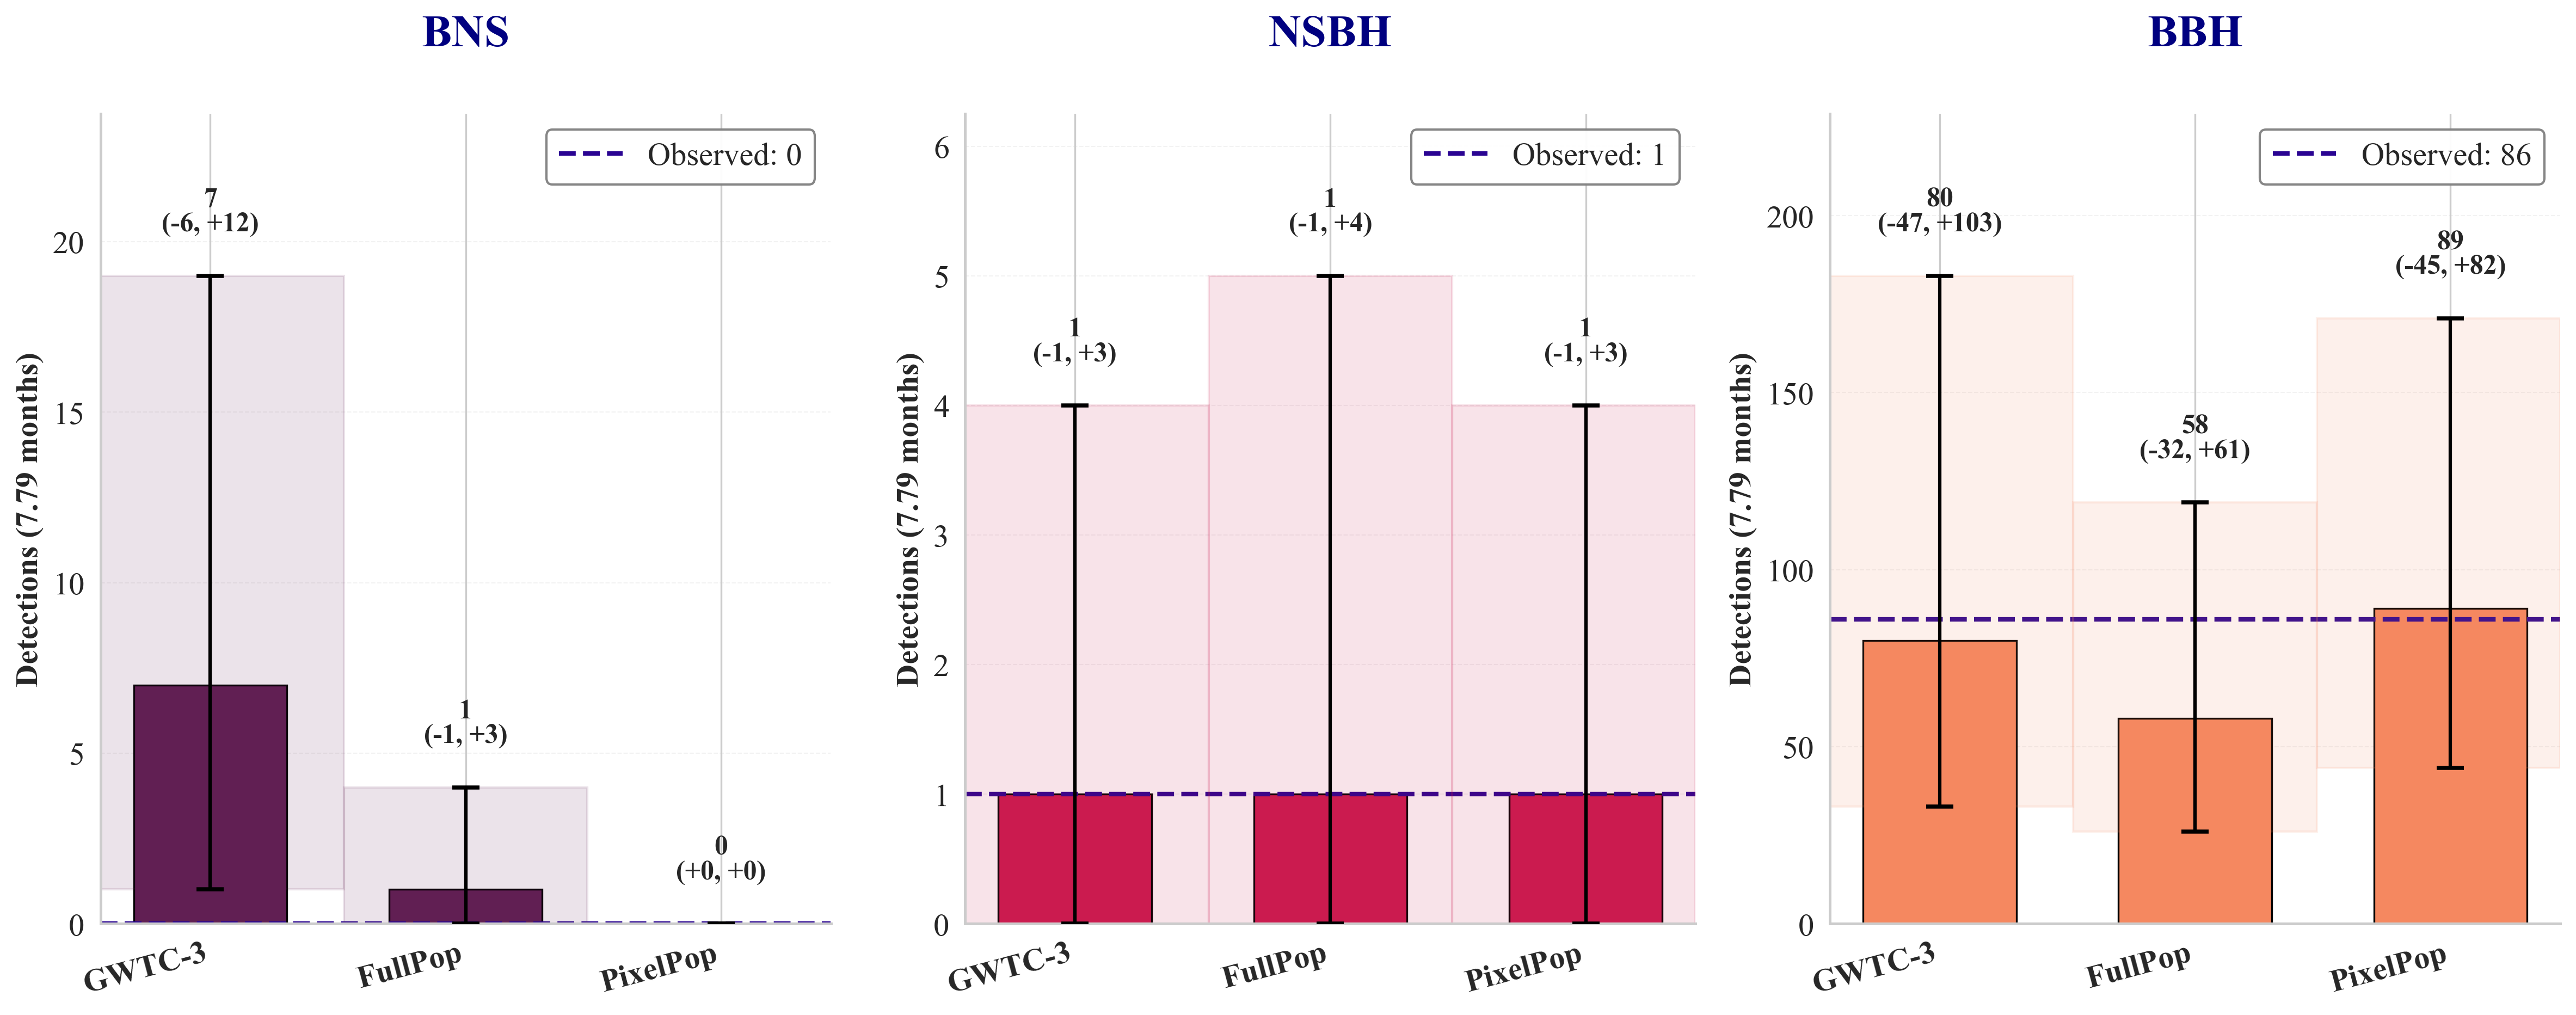

In [21]:
logger.info("GWTC-3, FullPop and PixelPop vs the O4a observation, spanning 7.79 months")

sns.set_style("whitegrid")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
plt.rcParams["font.size"] = 14
plt.rcParams["axes.linewidth"] = 1.2

bns_color, nsbh_color, bbh_color = sns.color_palette("rocket", 3)

# Recomputed here rather than read from all_results/observing_runs: both
# get reassigned by section "For Multiple distribution and different
# Fiducial" above (same variable names, different keys), so by this point
# in the notebook they no longer hold section 3's O4a results. rates_tables
# (section 3.1) is untouched by that section and safe to reuse.
_O4A_RUN_CONFIGS = {
    "GWTC-3": {
        "duration": run_durations["O4a"]["years"],
        "sim_rate": 8.209138761890435e-06,
        "detections": {"BNS": 405, "NSBH": 90, "BBH": 4222},
        "model": "gwtc3",
    },
    "FullPop": {
        "duration": run_durations["O4a"]["years"],
        "sim_rate": SIM_RATES["fullpop"],
        "detections": {"BNS": 121, "NSBH": 171, "BBH": 4184},
        "model": "fullpop",
    },
    "PixelPop": {
        "duration": run_durations["O4a"]["years"],
        "sim_rate": SIM_RATES["pixelpop"],
        "detections": {"BNS": 50, "NSBH": 119, "BBH": 5930},
        "model": "pixelpop",
    },
}


def _model_data(label):
    """(mid, lower_delta, upper_delta) per population, computed with the
    same rates_tables used in section 3, not hard-coded."""
    cfg = _O4A_RUN_CONFIGS[label]
    r = calculate_detection_rates(label, cfg, rates_tables[cfg["model"]])
    return {
        pop: {
            "mid": int(r["mid"][pop]),
            "lower_delta": -int(r["low"][pop]),
            "upper_delta": int(r["high"][pop]),
        }
        for pop in ["BNS", "NSBH", "BBH"]
    }


data = {
    "GWTC-3": _model_data("GWTC-3"),
    "FullPop": _model_data("FullPop"),
    "PixelPop": _model_data("PixelPop"),
    # O4a, FAR < 1/yr, from the GWOSC event catalog (GWTC-4.1, a
    # post-publication revision of GWTC-4.0's 86 O4a events -> 88 total).
    # One additional candidate (GW230630_070659, p_astro=0.96) has no
    # published component masses and is excluded from this breakdown.
    "Observed": {"BNS": 0, "NSBH": 1, "BBH": 86},
}

populations = ["BNS", "NSBH", "BBH"]
colors_pop = {"BNS": bns_color, "NSBH": nsbh_color, "BBH": bbh_color}

models = ["GWTC-3", "FullPop", "PixelPop"]

# Bounds
for model in models:
    for pop in populations:
        mid = data[model][pop]["mid"]
        lower_delta = data[model][pop]["lower_delta"]
        upper_delta = data[model][pop]["upper_delta"]
        data[model][pop]["low"] = mid + lower_delta
        data[model][pop]["high"] = mid + upper_delta

fig, axes = plt.subplots(1, 3, figsize=(16, 7), dpi=300)

for idx, pop in enumerate(populations):
    ax = axes[idx]

    x_pos = np.arange(len(models))
    predictions = []
    err_low = []
    err_high = []

    for model in models:
        mid = data[model][pop]["mid"]
        low = data[model][pop]["low"]
        high = data[model][pop]["high"]
        predictions.append(mid)
        err_low.append(mid - low)
        err_high.append(high - mid)

    # Plot bars
    bars = ax.bar(
        x_pos,
        predictions,
        width=0.6,
        color=colors_pop[pop],
        alpha=1,
        edgecolor="black",
        linewidth=0.8,
    )

    # Error bars
    ax.errorbar(
        x_pos,
        predictions,
        yerr=[err_low, err_high],
        fmt="none",
        ecolor="black",
        capsize=6,
        capthick=1.8,
        linewidth=1.5,
        zorder=5,
    )

    # Observed line
    obs_value = data["Observed"][pop]
    ax.axhline(
        y=obs_value,
        color="#2A0492",
        linestyle="--",
        linewidth=2,
        label=f"Observed: {obs_value}",
        zorder=1,
        alpha=1,
    )

    # Shaded CI regions
    for i, model in enumerate(models):
        low = data[model][pop]["low"]
        high = data[model][pop]["high"]
        ax.axhspan(
            low,
            high,
            xmin=i / len(models),
            xmax=(i + 1) / len(models),
            alpha=0.12,
            color=colors_pop[pop],
            zorder=1,
        )

    # Headroom above the tallest error bar, so labels never collide with
    # the plot's top edge or with each other regardless of how short or
    # tall the bars are relative to one another.
    top_of_bars = max(
        h for h in [predictions[i] + err_high[i] for i in range(len(models))]
    )
    ax.set_ylim(bottom=0, top=top_of_bars * 1.25)
    label_offset = top_of_bars * 0.06

    # Add numerical labels: value (lower_delta, upper_delta)
    for i, (bar, val) in enumerate(zip(bars, predictions)):
        model = models[i]
        lower_delta = data[model][pop]["lower_delta"]
        upper_delta = data[model][pop]["upper_delta"]

        text_y = val + err_high[i] + label_offset
        label_text = f"{val}\n({lower_delta:+d}, {upper_delta:+d})"

        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            text_y,
            label_text,
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            linespacing=1,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        models,
        fontsize=14,
        rotation=15,
        ha="right",
        fontweight="bold",
    )
    ax.set_ylabel("Detections (7.79 months)", fontsize=14, fontweight="bold")
    ax.set_title(f"{pop}", fontsize=20, fontweight="bold", pad=30, color="navy")
    ax.legend(fontsize=14, framealpha=0.95, edgecolor="gray")
    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()